In [106]:
import pandas as pd
import numpy as np
import torch

data = pd.read_csv("environments/Data/WMS/extracted_data.csv")
et_data = data["ET_0"]

# normalize the dataset and stores the mean and std

mean = et_data.mean()
std = et_data.std()

et_data = (et_data - mean) / std
et_data = torch.Tensor(et_data.values)

# Split the data into training and validation sets
split_ratio = 0.8
split_index = int(len(et_data) * split_ratio)

train_data = et_data[:split_index]
val_data = et_data[split_index:]

# create the dataloaders
from torch.utils.data import Dataset, DataLoader



class ETDataset(Dataset):
    def __init__(self, data, seq_length, output_steps=7):
        self.data = data
        self.seq_length = seq_length
        self.output_steps = output_steps

    def __len__(self):
        return len(self.data) - self.seq_length - self.output_steps + 1

    def __getitem__(self, index):
        x = self.data[index:index + self.seq_length]
        y = self.data[index + self.seq_length:index + self.seq_length + self.output_steps]
        return x, y

seq_length = 10






In [134]:
# modify the model to predict the next 7 steps
class LSTMModel(torch.nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, output_steps=7):
        super(LSTMModel, self).__init__()
        self.lstm = torch.nn.LSTM(n_features, hidden_size, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, output_steps)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out
    
    def predict(self, x):
        with torch.no_grad():
            self.eval()
            out = self.forward(x)
            return out
        
    def get_predictions(self, x:np.ndarray):
        x = torch.Tensor(x)
        return self.predict(x).numpy()


In [135]:
mdl = LSTMModel(n_features=1, hidden_size=64, num_layers=2)

mdl.predict(torch.ones((1, 10, 1)))

tensor([[-0.0780, -0.1556,  0.0443,  0.1241,  0.0079, -0.0790,  0.0124]])

In [136]:
# create a training loop

optimizer = torch.optim.Adam(mdl.parameters(), lr=0.001)
criterion = torch.nn.HuberLoss()
num_epochs = 100
batch_size = 512

dataset = ETDataset(et_data, seq_length)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

val_dataset = ETDataset(val_data, seq_length)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Training loop

for epoch in range(num_epochs):
    mdl.train()
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.unsqueeze(-1)  # Add feature dimension
        #y_batch = y_batch.unsqueeze(-1)  # Add feature dimension

        optimizer.zero_grad()
        outputs = mdl(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss / len(dataloader)}")

    # Validation loop
    if epoch % 10 == 0:
        mdl.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_dataloader:
                x_batch = x_batch.unsqueeze(-1)
                #y_batch = y_batch.unsqueeze(-1)
                outputs = mdl(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        print(f"Validation Loss: {val_loss / len(val_dataloader)}")


Epoch 1/100, Loss: 0.3317090980708599
Validation Loss: 0.10121992106239001
Epoch 2/100, Loss: 0.08136201596685819
Epoch 3/100, Loss: 0.06075942130493266
Epoch 4/100, Loss: 0.05610229154782636
Epoch 5/100, Loss: 0.05505914640213762
Epoch 6/100, Loss: 0.05455590398716075
Epoch 7/100, Loss: 0.05429375411144325
Epoch 8/100, Loss: 0.053924168327025006
Epoch 9/100, Loss: 0.05355541620935712
Epoch 10/100, Loss: 0.053576494833188396
Epoch 11/100, Loss: 0.0533432975145323
Validation Loss: 0.05925779975950718
Epoch 12/100, Loss: 0.05306680074759892
Epoch 13/100, Loss: 0.05294352982725416
Epoch 14/100, Loss: 0.052582177333533764
Epoch 15/100, Loss: 0.05239311845174858
Epoch 16/100, Loss: 0.052397457350577624
Epoch 17/100, Loss: 0.05218225371624742
Epoch 18/100, Loss: 0.05178159408803497
Epoch 19/100, Loss: 0.051683955027588775
Epoch 20/100, Loss: 0.051397648373884816
Epoch 21/100, Loss: 0.051226996151464324
Validation Loss: 0.056749251360694565
Epoch 22/100, Loss: 0.05090173812849181
Epoch 23/100

In [139]:
# save the model
torch.save(mdl, "environments/Data/WMS/lstm_model.pth")
#save the mean and std
mean_std = {"mean": mean, "std": std}
torch.save(mean_std, "environments/Data/WMS/mean_std.pth")

# load the model
mdl = torch.load("environments/Data/WMS/lstm_model.pth", weights_only=False)
#mean, std = torch.load("environments/Data/WMS/mean_std.pth")["mean"], torch.load("environments/Data/WMS/mean_std.pth")["std"]

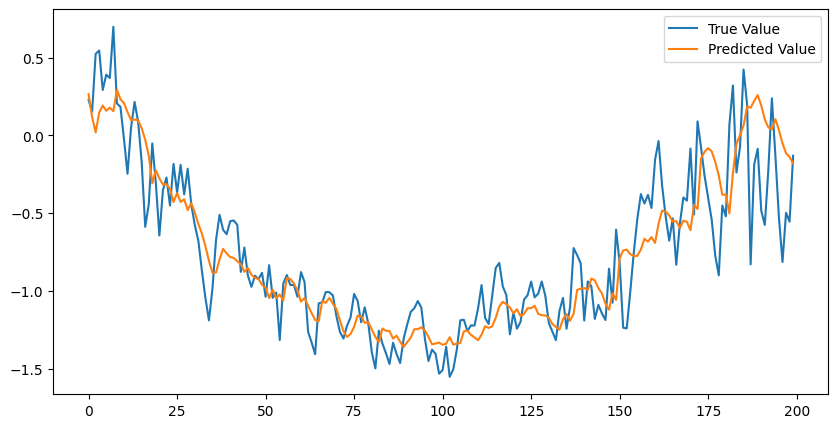

In [140]:
# plot the results

import matplotlib.pyplot as plt
len_data = 200

predictions = np.zeros(len_data)
real_values = np.zeros(len_data) 
for i in range(len_data):
    
    input = val_data[i:i + seq_length]
    input = torch.Tensor(input).unsqueeze(0).unsqueeze(-1)  # Add batch and feature dimensions
    y_pred = mdl.predict(input).squeeze().numpy()[-1]
    y_true = val_data[i + seq_length].numpy()
    predictions[i] = y_pred
    real_values[i] = y_true

plt.figure(figsize=(10, 5))
t = np.arange(len_data)
plt.plot(t,real_values, label="True Value")
plt.plot(t,predictions, label="Predicted Value")
plt.legend()
plt.show()

In [146]:
mdl.predict(input).squeeze().numpy()

array([-0.45984825, -0.34293658, -0.2894005 , -0.2541426 , -0.21606001,
       -0.19945826, -0.18008927], dtype=float32)